In [ ]:
!pip install langgraph langchain langchain_huggingface dotenv

### 1) Non-LLM Workflow

In [29]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

In [30]:
# define state
class BMIState(TypedDict):
  height_m: float
  weight_kg: float
  bmi: float
  category: str

In [31]:
# Node -> calculateBMI
def calculateBMI(state : BMIState) -> BMIState:
  state['bmi'] = round(state['weight_kg'] / (state['height_m'] ** 2), 2)
  return state

In [32]:
def defineCategory(state: BMIState) -> BMIState:
  if state['bmi'] > 30:
    state['category'] = 'OBESE'
  elif 25 < state['bmi'] <= 30:
    state['category'] = 'OVERWEIGHT'
  elif 18.5 < state['bmi'] <= 25:
    state['category'] = 'NORMAL'
  else :
    state['category'] = 'UNDERWEIGHT'
  return state

In [33]:
# define graph
graph = StateGraph(BMIState)

In [34]:
# add nodes to your graph
graph.add_node('calculateBMI', calculateBMI)
graph.add_node('defineCategory', defineCategory)

In [35]:
# add edges to your graph

# START -> calculateBMI'
graph.add_edge(START, 'calculateBMI')

# calculateBMI -> defineCategory
graph.add_edge('calculateBMI', 'defineCategory')

# definecategory -> END
graph.add_edge('defineCategory', END)

In [37]:
# compile the graph
bmiWorkflow = graph.compile()

In [43]:
# Execute the graph
bmiWorkflow.invoke({'height_m': 1.73, 'weight_kg': 70.81})

{'height_m': 1.73, 'weight_kg': 70.81, 'bmi': 23.66, 'category': 'NORMAL'}

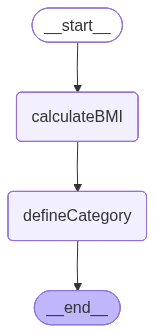

In [39]:
from IPython.display import Image
Image(bmiWorkflow.get_graph().draw_mermaid_png())

### 2) LLM Workflow

In [ ]:
# from google.colab import userdata
# userdata.get('HUGGINGFACEHUB_API_TOKEN')

In [48]:
# import os
# os.environ["HUGGINGFACEHUB_API_TOKEN"] = ""

In [52]:
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import  StrOutputParser

In [49]:
from langchain_huggingface import HuggingFaceEndpoint, ChatHuggingFace
llm = HuggingFaceEndpoint(
    repo_id = "Qwen/Qwen3-4B-Instruct-2507",
    task = "text-generation",
)
model = ChatHuggingFace(llm = llm)

In [51]:
# Define State
class LLMState(TypedDict):
  query : str
  response : str

In [58]:
def llmQA(state: LLMState) -> LLMState:
  prompt = PromptTemplate(
      template = "Give a brief but detailed response to this query{query}.",
      input_variables= ['query']
  )
  parser = StrOutputParser()
  query = state['query']
  chain = prompt | model | parser
  response = chain.invoke({'query': query})
  state['response'] = response
  return state

In [59]:
# Define Graph
llmGraph = StateGraph(LLMState)

# Add Node
llmGraph.add_node('llmQA', llmQA)

# Add edges
llmGraph.add_edge(START, 'llmQA')
llmGraph.add_edge('llmQA', END)

# Compile Graph
llmQAWorkflow = llmGraph.compile()

# Execute the graph
llmQAWorkflow.invoke({'query': 'What is the capital of France?'})

{'query': 'What is the capital of France?',
 'response': 'The capital of France is Paris. Located in the northern part of the country, Paris is not only the political and administrative center of France but also a major cultural, historical, and economic hub. It is renowned for landmarks such as the Eiffel Tower, the Louvre Museum, and the Notre-Dame Cathedral. As the seat of the French government, including the Élysée Palace and the National Assembly, Paris serves as the heart of France’s national institutions.'}

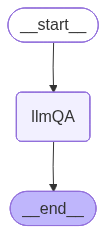

In [ ]:
from IPython.display import Image
Image(llmQAWorkflow.get_graph().draw_mermaid_png())

### 3) Prompt Chaining

In [62]:
# Define State
class BlogState(TypedDict):
  topic : str
  outline : str
  blog : str

In [64]:
def generateOutline(state: BlogState) -> BlogState:
  topic = state['topic']
  prompt = PromptTemplate(
      template = "Generate a detailed outline for this provided topic, which can provide better information to generate a blog on this given topic:{topic}.",
      input_variables= ['topic']
  )
  parser = StrOutputParser()
  chain = prompt | model | parser
  outline = chain.invoke({'topic': topic})
  state['outline'] = outline
  return state


In [66]:
def generateBlog(state: BlogState) -> BlogState:
  outline = state['outline']
  prompt = PromptTemplate(
      template = "Write a 300-400 words, detailed and topic specific blog on this outline:{outline}.",
      input_variables= ['outline']
  )
  parser = StrOutputParser()
  chain = prompt | model | parser
  blog = chain.invoke({'outline': outline})
  state['blog'] = blog
  return state

In [69]:
# Define Graph
blogGraph = StateGraph(BlogState)

# Add Nodes
blogGraph.add_node('generateOutline', generateOutline)
blogGraph.add_node('generateBlog', generateBlog)

# Add Edges
blogGraph.add_edge(START, 'generateOutline')
blogGraph.add_edge('generateOutline', 'generateBlog')
blogGraph.add_edge('generateBlog', END)

# Compile Graph
blogWorkflow = blogGraph.compile()

# Execute Graph
response = blogWorkflow.invoke({'topic': 'Machine Learning'})

In [72]:
print(response['blog'])

**Understanding Machine Learning – A Comprehensive Guide for Beginners and Beyond**

Machine learning (ML) is a subset of artificial intelligence that enables systems to learn from data, identify patterns, and make decisions—without being explicitly programmed for each task. Unlike traditional programming, where rules are manually coded, ML algorithms improve over time by analyzing vast datasets. Think of it like teaching a child to recognize cats: you show them thousands of photos labeled “cat” or “not cat,” and gradually, they begin to spot cats on their own.

The evolution of ML has been driven by technological advances. From early symbolic AI in the 1950s to the rise of neural networks in the 1980s and 1990s, ML gained momentum with the explosion of internet data, smartphones, and cloud computing in the 2000s. Today’s deep learning models—like neural networks with millions of parameters—power applications from facial recognition to self-driving cars.

At its core, ML operates on th

In [71]:
print(response['outline'])

Certainly! Here's a **comprehensive and detailed outline** for a blog on **Machine Learning**, designed to provide depth, clarity, accessibility, and engagement for a broad audience—beginners to intermediate readers. This outline covers foundational concepts, real-world applications, key techniques, challenges, and future trends, all structured logically to guide a well-organized and informative blog post.

---

# **Blog Outline: Understanding Machine Learning – A Comprehensive Guide for Beginners and Beyond**

---

## **I. Introduction: What is Machine Learning?**
- Define machine learning (ML) in simple terms (learning from data to make predictions or decisions)
- Contrast with traditional programming (explicit instructions vs. data-driven learning)
- Use a relatable analogy (e.g., teaching a child to recognize cats through photos)
- Why machine learning matters today: automation, AI, data-driven decisions

---

## **II. The Evolution of Machine Learning**
- Historical milestones:
  